In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score

In [32]:
df= pd.read_csv("spam.csv", encoding= 'latin-1')
print(df.columns)
df= df.iloc[:,[0,1]]
df.columns= ['label', 'message']
df= df.dropna()

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')


In [33]:
print(df.head())
print(df.columns)

  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...
Index(['label', 'message'], dtype='object')


In [34]:
df['label']= df['label'].map({'ham':0, 'spam':1})

In [35]:
print(df.columns)

Index(['label', 'message'], dtype='object')


In [36]:
print(df.isnull().sum())

label      0
message    0
dtype: int64


In [37]:
df['label']= pd.to_numeric(df['label'], errors= 'coerce')
df= df.dropna(subset=['label'])
df['label']= df['label'].astype(int)

In [38]:
print(df['label'].dtype)
print(df['label'].unique())

int64
[0 1]


In [39]:
x= df["message"]
y= df["label"]

In [40]:
print(x.head())
print(y.head())

0    Go until jurong point, crazy.. Available only ...
1                        Ok lar... Joking wif u oni...
2    Free entry in 2 a wkly comp to win FA Cup fina...
3    U dun say so early hor... U c already then say...
4    Nah I don't think he goes to usf, he lives aro...
Name: message, dtype: object
0    0
1    0
2    1
3    0
4    0
Name: label, dtype: int64


In [41]:
x_train, x_test, y_train, y_test= train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

In [42]:
cv= CountVectorizer()

In [43]:
x_train_cv= cv.fit_transform(x_train)
x_test_cv= cv.transform(x_test)

In [44]:
print(x_train_cv.shape)
print(x_test_cv.shape)

(4457, 7735)
(1115, 7735)


In [45]:
print(df['label'].dtype)

int64


In [46]:
from sklearn.naive_bayes import MultinomialNB

model_cv= MultinomialNB()

print(type(x_train_cv))
print(type(y_train))
    
model_cv.fit(x_train_cv, y_train)

<class 'scipy.sparse._csr.csr_matrix'>
<class 'pandas.core.series.Series'>


,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [47]:
y_pred_cv= model_cv.predict(x_test_cv)

In [48]:
accuracy_cv= (accuracy_score(y_test, y_pred_cv))
print("Accuracy:",accuracy_cv)

Accuracy: 0.9838565022421525


In [49]:
cm_cv= confusion_matrix(y_test, y_pred_cv)
print(cm_cv)

[[963   2]
 [ 16 134]]


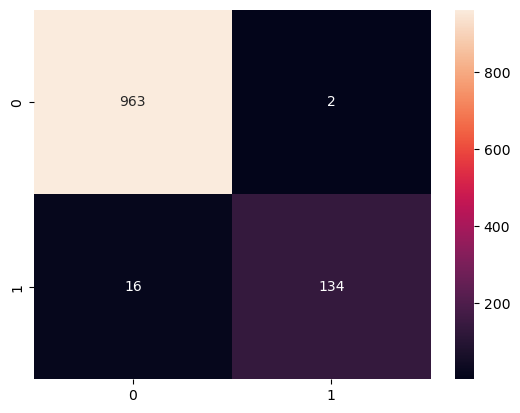

In [50]:
sns.heatmap(
    cm_cv,
    annot=True,
    fmt='d'
)
plt.show()

In [51]:
print(classification_report(y_test, y_pred_cv))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       965
           1       0.99      0.89      0.94       150

    accuracy                           0.98      1115
   macro avg       0.98      0.95      0.96      1115
weighted avg       0.98      0.98      0.98      1115



In [52]:
vectorizer= TfidfVectorizer(stop_words='english')
x_train_vec= vectorizer.fit_transform(x_train)
x_test_vec= vectorizer.transform(x_test)

In [53]:
model= MultinomialNB()

model.fit(
    x_train_vec,
    y_train
)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [54]:
y_pred= model.predict(x_test_vec)

In [62]:
from sklearn.metrics import accuracy_score

y_pred_tf= model.predict(x_test_vec)
accuracy_tf= accuracy_score(y_test, y_pred_tf)

print("TF-IDF Accuracy:",accuracy_tf)

TF-IDF Accuracy: 0.9668161434977578


In [61]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       965
           1       1.00      0.75      0.86       150

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.96      1115



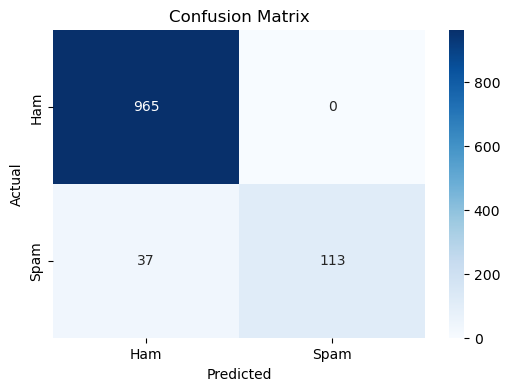

In [57]:
cm= confusion_matrix(y_test,y_pred)

import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot= True, fmt='d', cmap= 'Blues',
            xticklabels=['Ham','Spam'],
            yticklabels=['Ham','Spam'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [63]:
results= pd.DataFrame({
    "Model":["CountVectorizer","TF-IDF"],
    "Accuracy":[accuracy_cv,accuracy_tf]
})
print(results)

             Model  Accuracy
0  CountVectorizer  0.983857
1           TF-IDF  0.966816


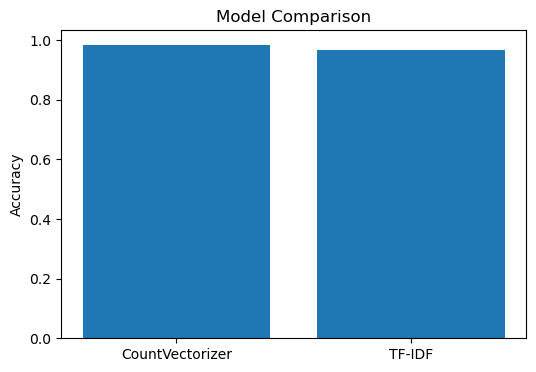

In [65]:
import pandas as pd
import matplotlib.pyplot as plt

results= pd.DataFrame({
    "Model":["CountVectorizer", "TF-IDF"],
    "Accuracy":[accuracy_cv, accuracy_tf]
})

plt.figure(figsize=(6,4))
plt.bar(results["Model"],results["Accuracy"])
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()